<a href="https://colab.research.google.com/github/laceywang11/MSSP6070/blob/main/Assignment3_Code_Lacey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

Saving HousingPrices.csv to HousingPrices.csv


In [3]:
df = pd.read_csv("HousingPrices.csv")
df.head()

,Id,LotFrontage,LotArea,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,CentralAir,1stFlrSF,2ndFlrSF,FullBath,TotalRooms,GarageCars,GarageArea,YrSold,SalePrice
0,1,65.0,8450.0,2Story,7,5,2003,856.0,Y,856,854,2,8,2,548,2008,208500
1,2,80.0,9600.0,1Story,6,8,1976,NaN,Y,1262,0,2,6,2,460,2007,181500
2,3,68.0,11250.0,2Story,7,5,2001,920.0,Y,920,866,2,6,2,608,2008,223500
3,4,60.0,9550.0,2Story,7,5,1915,NaN,Y,961,756,1,7,3,642,2006,140000
4,5,84.0,14260.0,2Story,8,5,2000,1145.0,Y,1145,1053,2,9,3,836,2008,250000


In [4]:
df.describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,FullBath,TotalRooms,GarageCars,GarageArea,YrSold,SalePrice
count,1460.000000,1201.000000,1341.000000,1460.000000,1460.000000,1460.000000,913.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,70.049958,10440.099925,6.099315,5.575342,1971.267808,1055.813801,1162.626712,346.992466,1.565068,6.517808,1.767123,472.980137,2007.815753,180921.195890
std,421.610009,24.284752,10051.013206,1.382997,1.112799,30.202904,409.495459,386.587738,436.528436,0.550916,1.625393,0.747315,213.804841,1.328095,79442.502883
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,0.000000,334.000000,0.000000,0.000000,2.000000,0.000000,0.000000,2006.000000,34900.000000
25%,365.750000,59.000000,7500.000000,5.000000,5.000000,1954.000000,806.000000,882.000000,0.000000,1.000000,5.000000,1.000000,334.500000,2007.000000,129975.000000
50%,730.500000,69.000000,9382.000000,6.000000,5.000000,1973.000000,996.000000,1087.000000,0.000000,2.000000,6.000000,2.000000,480.000000,2008.000000,163000.000000
75%,1095.250000,80.000000,11500.000000,7.000000,6.000000,2000.000000,1286.000000,1391.250000,728.000000,2.000000,7.000000,2.000000,576.000000,2009.000000,214000.000000
max,1460.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,3206.000000,4692.000000,2065.000000,3.000000,14.000000,4.000000,1418.000000,2010.000000,755000.000000


**1. What is the mean and standard deviation of the price of housing?**

In [5]:
mean_price = df["SalePrice"].mean()
std_price = df["SalePrice"].std()
print("Average sale price (mean):", mean_price)
print("Price standard deviation (std):", std_price)

Average sale price (mean): 180921.19589041095
Price standard deviation (std): 79442.50288288663


**2. Generate a histogram of the housing price.**

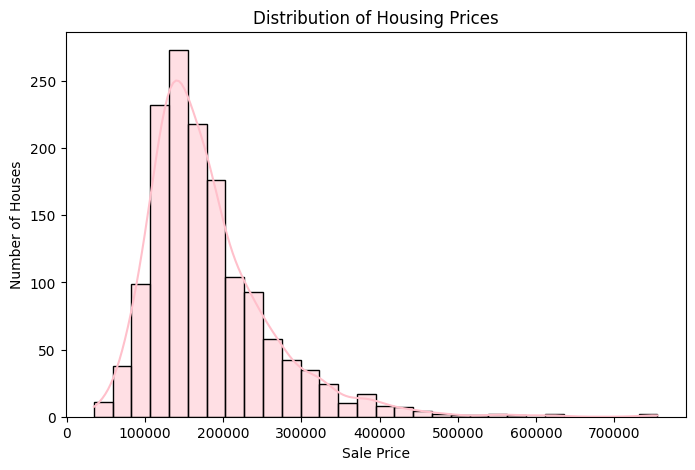

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], bins=30, kde=True, color="pink")
plt.title("Distribution of Housing Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.show()

**3. Are there any outliers that may impact the analysis?  How would you handle the outliers if identified?**

In [7]:
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: 3937.5
Upper bound: 340037.5


In [8]:
outliers = df[(df["SalePrice"] < lower_bound) | (df["SalePrice"] > upper_bound)]
print("Number of outliers:", len(outliers))

Number of outliers: 61


In [15]:
top10 = df.sort_values("SalePrice", ascending=False).head(10)
top10[["SalePrice"]]

,SalePrice
691,755000
1182,745000
1169,625000
898,611657
803,582933
1046,556581
440,555000
769,538000
178,501837
798,485000


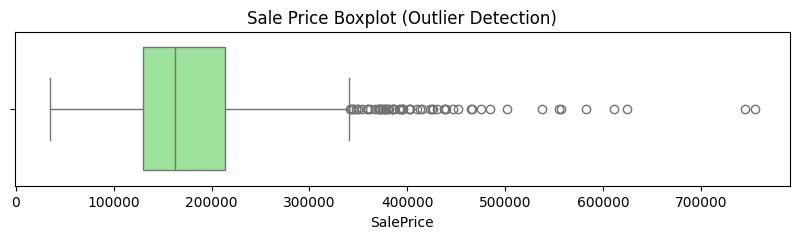

In [9]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df["SalePrice"], color="lightgreen")
plt.title("Sale Price Boxplot (Outlier Detection)")
plt.show()

In [10]:
df["LogSalePrice"] = np.log(df["SalePrice"])
df.head()

,Id,LotFrontage,LotArea,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,CentralAir,1stFlrSF,2ndFlrSF,FullBath,TotalRooms,GarageCars,GarageArea,YrSold,SalePrice,LogSalePrice
0,1,65.0,8450.0,2Story,7,5,2003,856.0,Y,856,854,2,8,2,548,2008,208500,12.247694
1,2,80.0,9600.0,1Story,6,8,1976,NaN,Y,1262,0,2,6,2,460,2007,181500,12.109011
2,3,68.0,11250.0,2Story,7,5,2001,920.0,Y,920,866,2,6,2,608,2008,223500,12.317167
3,4,60.0,9550.0,2Story,7,5,1915,NaN,Y,961,756,1,7,3,642,2006,140000,11.849398
4,5,84.0,14260.0,2Story,8,5,2000,1145.0,Y,1145,1053,2,9,3,836,2008,250000,12.429216


In [14]:
df["LogSalePrice"].describe()

,LogSalePrice
count,1460.000000
mean,12.024051
std,0.399452
min,10.460242
25%,11.775097
50%,12.001505
75%,12.273731
max,13.534473


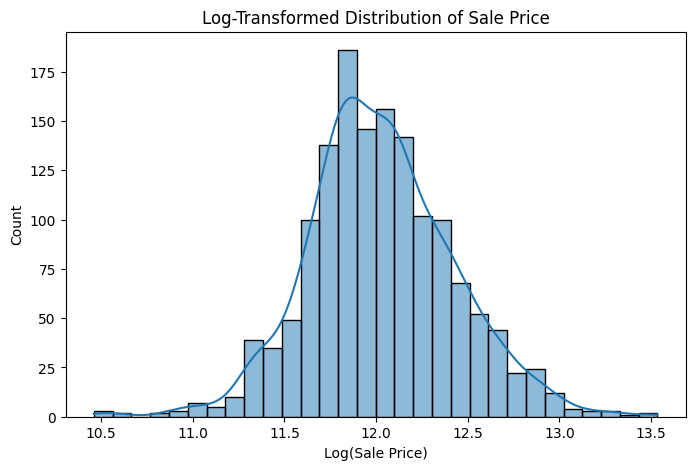

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df["LogSalePrice"], bins=30, kde=True)
plt.title("Log-Transformed Distribution of Sale Price")
plt.xlabel("Log(Sale Price)")
plt.ylabel("Count")
plt.show()

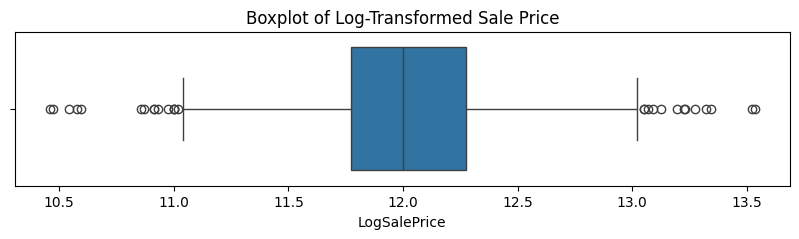

In [12]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df["LogSalePrice"])
plt.title("Boxplot of Log-Transformed Sale Price")
plt.show()

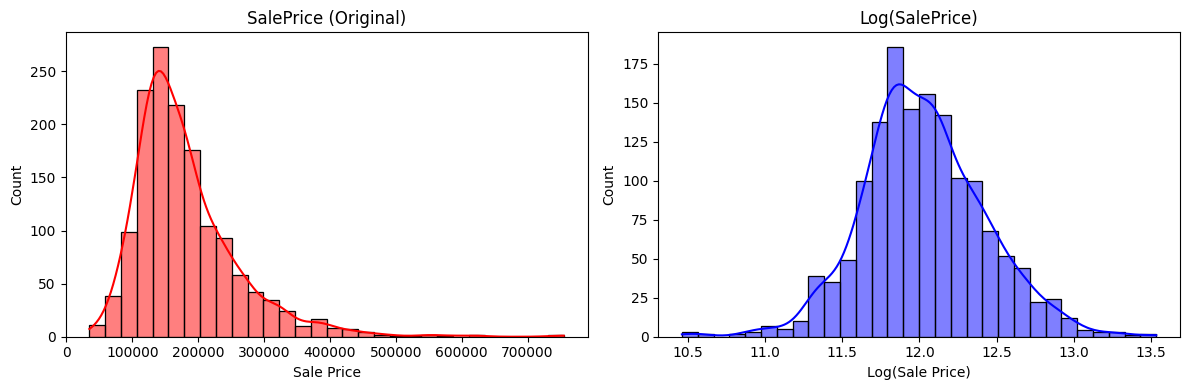

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["SalePrice"], bins=30, kde=True, ax=axes[0], color="red")
axes[0].set_title("SalePrice (Original)")
axes[0].set_xlabel("Sale Price")
axes[0].set_ylabel("Count")

sns.histplot(df["LogSalePrice"], bins=30, kde=True, ax=axes[1], color="blue")
axes[1].set_title("Log(SalePrice)")
axes[1].set_xlabel("Log(Sale Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()